In [1]:
from datetime import datetime
import os
import pickle
import numpy as np
import pandas as pd

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from generation.utils import plot_iv_surface
from generation.surface_generation import generate_surfaces, SimulationConfig
from models.framework import DeepONet, MLP

# ============================================================
# 1️⃣ Generate synthetic Rough Bergomi IV surfaces
# ============================================================

# cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=2)
# surfaces = generate_surfaces(
#     num_sets=10,
#     forward_curves_per_set=10,
#     cfg=cfg,
#     seed=4235,
#     randomize_grid=True,
# )


SAVE_ROOT = "data/longrun"
surfaces = []

# List and sort all batch files (batch_0000.pkl, batch_0001.pkl, ...)
batch_files = sorted([
    f for f in os.listdir(SAVE_ROOT)
    if f.startswith("batch_") and f.endswith(".pkl")
])

# print(f"Found {len(batch_files)} batch files.")

for fname in batch_files:
    path = os.path.join(SAVE_ROOT, fname)
    try:
        with open(path, "rb") as f:
            data = pickle.load(f)
            # If each file stores {"surfaces": [...]} dicts:
            if isinstance(data, dict) and "surfaces" in data:
                surfaces.extend(data["surfaces"])
            # Or if it’s already a list:
            elif isinstance(data, list):
                surfaces.extend(data)
            else:
                print(f"⚠️ Unrecognized format in {fname}")
        print(f"Loaded {fname}")
    except Exception as e:
        print(f"❌ Error loading {fname}: {e}")

print(f"\n✅ Total surfaces loaded: {len(surfaces)}")


Loaded batch_0000.pkl
Loaded batch_0001.pkl
Loaded batch_0002.pkl
Loaded batch_0003.pkl
Loaded batch_0004.pkl
Loaded batch_0005.pkl

✅ Total surfaces loaded: 6000


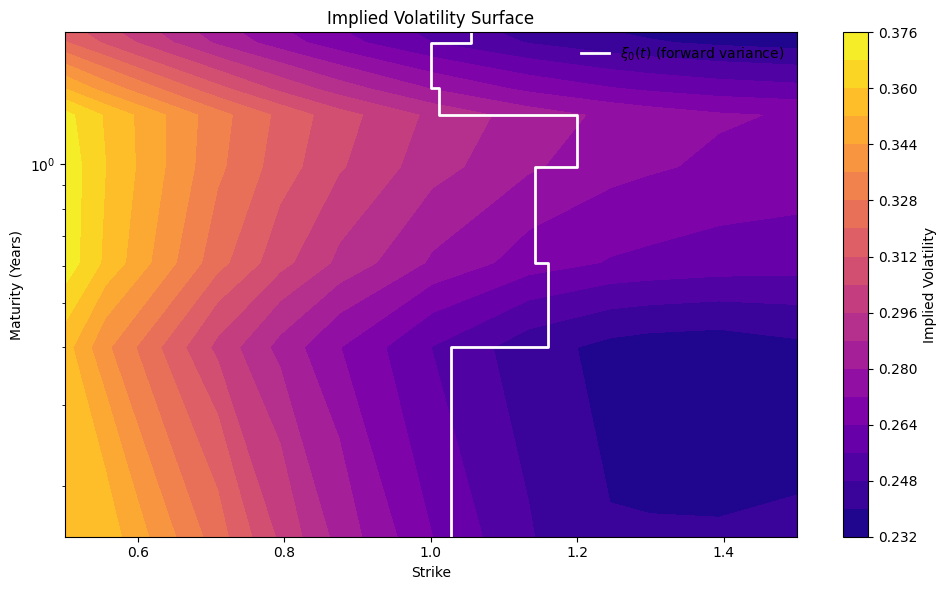

In [2]:
k = 141
x = surfaces[k]["iv_surface"]
xi0_knots = np.array(surfaces[k]["params"]["xi0_knots"])
maturities = np.array(surfaces[k]["grid"]["maturities"])
strikes = np.array(surfaces[k]["grid"]["strikes"])

# --- reconstruct bin edges for piecewise-constant ξ₀(t) ---
# first edge starts at 0, last one ends at the final maturity
edges = np.concatenate([[0.0], maturities])

plot_iv_surface(
    x, strikes, maturities,
    xi0_knots=xi0_knots,      # K values
    xi0_bin_edges=edges,      # K+1 edges
)



In [3]:
train_surfaces = surfaces[:5500]
test_surfaces = surfaces[5500:]

train_loader, val_loader, bdim, Ks, Ts = MLP.prepare_data(train_surfaces)
model = DeepONet(branch_in_dim=bdim, latent_dim=64, hidden_dim=64, lr=1e-3)
model.set_grid(Ks, Ts)
model.set_io_dims(input_dim=bdim)
model.train_model(train_loader, val_loader, epochs=10)
fig = model.plot_evaluation(test_surfaces[0])  # no extra args needed
model.evaluate_and_save(test_surfaces, out_dir="deeponet_eval")

ValueError: All surfaces must share the same (K, T) grid for the MLP output shape.

In [4]:
test_surfaces[0]

IndexError: list index out of range

# Consistency check 

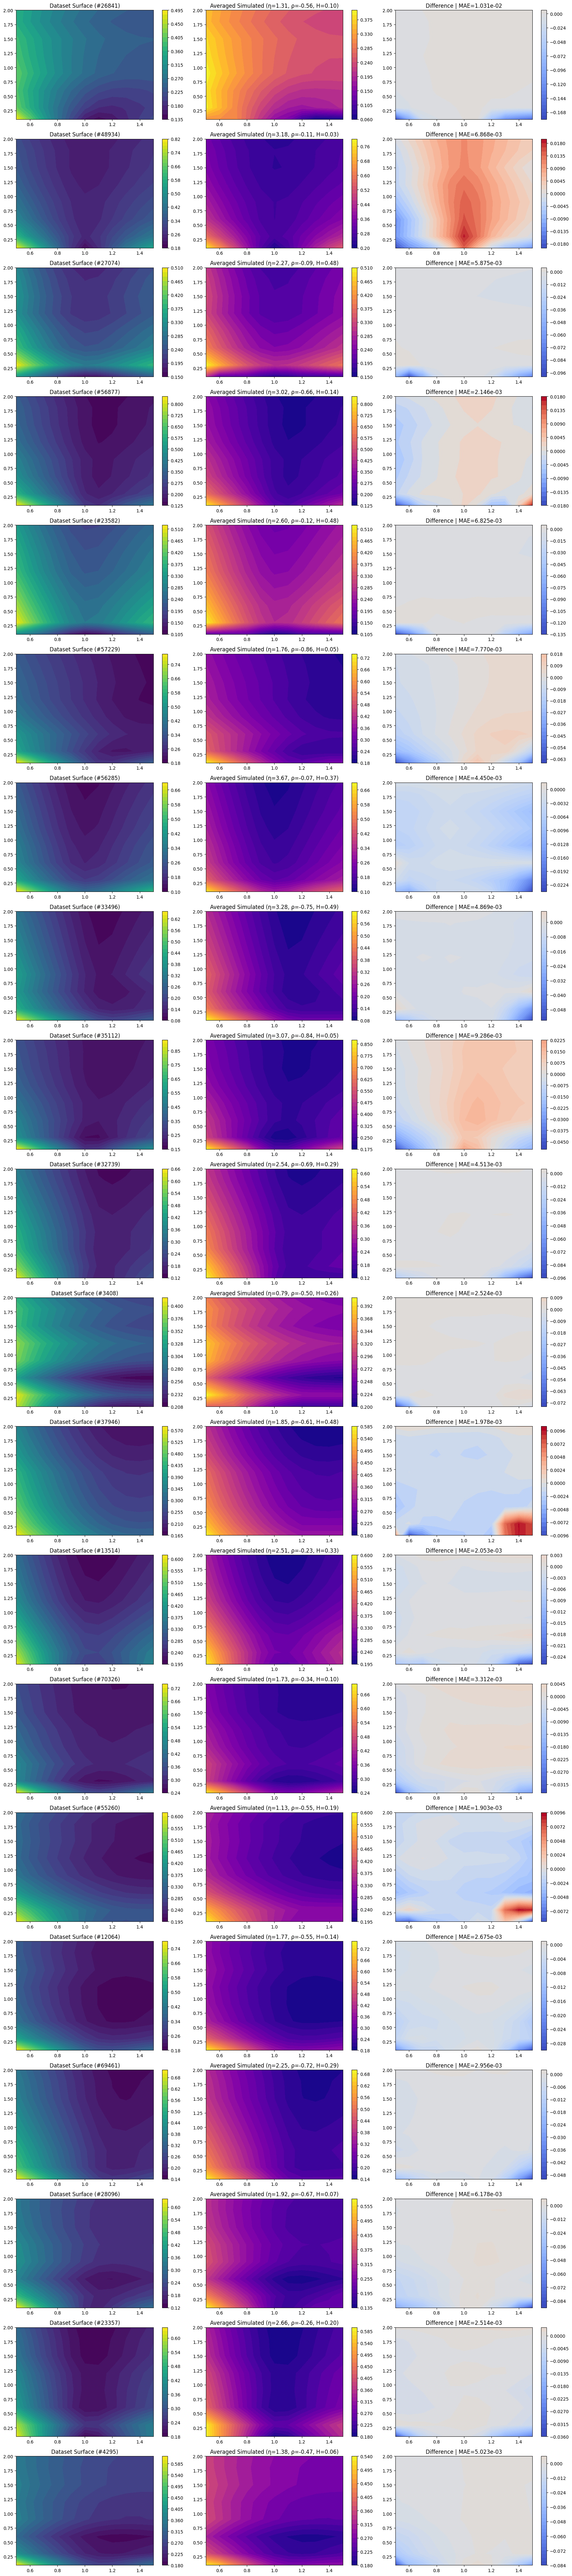

Comparison summary (averaged over seeds):
Idx 26841 | η=1.310, ρ=-0.560, H=0.099 | MAE=1.031e-02
Idx 48934 | η=3.183, ρ=-0.114, H=0.032 | MAE=6.868e-03
Idx 27074 | η=2.271, ρ=-0.089, H=0.482 | MAE=5.875e-03
Idx 56877 | η=3.024, ρ=-0.660, H=0.139 | MAE=2.146e-03
Idx 23582 | η=2.600, ρ=-0.121, H=0.479 | MAE=6.825e-03
Idx 57229 | η=1.760, ρ=-0.860, H=0.054 | MAE=7.770e-03
Idx 56285 | η=3.671, ρ=-0.072, H=0.366 | MAE=4.450e-03
Idx 33496 | η=3.281, ρ=-0.753, H=0.486 | MAE=4.869e-03
Idx 35112 | η=3.073, ρ=-0.843, H=0.046 | MAE=9.286e-03
Idx 32739 | η=2.538, ρ=-0.695, H=0.286 | MAE=4.513e-03
Idx 3408 | η=0.795, ρ=-0.501, H=0.258 | MAE=2.524e-03
Idx 37946 | η=1.851, ρ=-0.612, H=0.481 | MAE=1.978e-03
Idx 13514 | η=2.508, ρ=-0.233, H=0.334 | MAE=2.053e-03
Idx 70326 | η=1.727, ρ=-0.339, H=0.099 | MAE=3.312e-03
Idx 55260 | η=1.129, ρ=-0.548, H=0.192 | MAE=1.903e-03
Idx 12064 | η=1.772, ρ=-0.549, H=0.140 | MAE=2.675e-03
Idx 69461 | η=2.248, ρ=-0.719, H=0.295 | MAE=2.956e-03
Idx 28096 | η=1.921, ρ=-

In [1]:
import sys, os, gzip
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import matplotlib.pyplot as plt
from generation.surface_generation import generate_fixed_surface, SimulationConfig

# ======================================================
# 1️⃣ Load data
# ======================================================

f = gzip.GzipFile("../OriginalCode/TrainrBergomiTermStructure.txt.gz", "r")
dat = np.load(f)
xx = dat[:, :11]
yy = dat[:, 11:]

strikes = np.array([0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5])
maturities = np.array([0.1, 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.0])

cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=1)

# ======================================================
# 2️⃣ Define subset of parameter sets to test
# ======================================================
num_tests = 20        # number of parameter combinations to test
num_seeds = 1        # how many seeds to average over
np.random.seed(1230)
test_indices = np.random.choice(len(xx), num_tests, replace=False)

# ======================================================
# 3️⃣ Run simulations and compare
# ======================================================
results = []
fig, axs = plt.subplots(num_tests, 3, figsize=(18, 4 * num_tests))
if num_tests == 1:
    axs = axs.reshape(1, -1)

for row, idx in enumerate(test_indices):
    xi0_knots = xx[idx, :8]
    eta, rho, H = xx[idx, 8:11]
    param_set = {"eta": float(eta), "rho": float(rho), "H": float(H)}

    # Average several random seeds
    sim_surfaces = []
    for s in range(num_seeds):
        seed_val = 400 + s * 17  # any deterministic spacing
        surf = generate_fixed_surface(param_set, xi0_knots, strikes, maturities, cfg, seed=seed_val)
        sim_surfaces.append(surf["iv_surface"])
    sim_surface = np.mean(sim_surfaces, axis=0)

    # True dataset surface
    true_surface = yy[idx].reshape(len(maturities), len(strikes))

    diff = sim_surface - true_surface
    mae = np.mean(np.abs(diff))
    results.append({"idx": idx, "eta": eta, "rho": rho, "H": H, "mae": mae})

    K, T = np.meshgrid(strikes, maturities)

    # Plot
    c0 = axs[row, 0].contourf(K, T, true_surface, levels=30, cmap="viridis")
    axs[row, 0].set_title(f"Dataset Surface (#{idx})")
    plt.colorbar(c0, ax=axs[row, 0])

    c1 = axs[row, 1].contourf(K, T, sim_surface, levels=30, cmap="plasma")
    axs[row, 1].set_title(f"Averaged Simulated (η={eta:.2f}, ρ={rho:.2f}, H={H:.2f})")
    plt.colorbar(c1, ax=axs[row, 1])

    vmax = np.max(np.abs(diff))
    c2 = axs[row, 2].contourf(K, T, diff, levels=30, cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axs[row, 2].set_title(f"Difference | MAE={mae:.3e}")
    plt.colorbar(c2, ax=axs[row, 2])

plt.tight_layout()
plt.show()

# ======================================================
# 4️⃣ Print summary stats
# ======================================================
print("Comparison summary (averaged over seeds):")
for r in results:
    print(f"Idx {r['idx']:>4} | η={r['eta']:.3f}, ρ={r['rho']:.3f}, H={r['H']:.3f} | MAE={r['mae']:.3e}")


In [3]:
xi0_knots

array([0.060387 , 0.0915571, 0.111914 , 0.0787501, 0.0586107, 0.0106722,
       0.138683 , 0.121228 ])